# 01_Regression_Metrics.ipynb

# Section 1 — Introduction

---

# What are Regression Metrics?

After training a regression model, we need a way to measure **how good its predictions are**.

Regression metrics compare the **actual target values** with the **predicted values** and summarize the model's performance using numerical scores.

Without evaluation metrics, we cannot determine:

* Whether the model is performing well.
* Whether one model is better than another.
* Whether changes to the model improve performance.

---

## Why do we need Regression Metrics?

Consider a house price prediction model.

| House | Actual Price | Predicted Price |
| ----- | -----------: | --------------: |
| 1     |   ₹50,00,000 |      ₹49,50,000 |
| 2     |   ₹70,00,000 |      ₹72,00,000 |
| 3     |   ₹40,00,000 |      ₹38,50,000 |

The predictions are close, but **how close?**

Now consider another model:

| House | Actual Price | Predicted Price |
| ----- | -----------: | --------------: |
| 1     |   ₹50,00,000 |      ₹35,00,000 |
| 2     |   ₹70,00,000 |      ₹92,00,000 |
| 3     |   ₹40,00,000 |      ₹18,00,000 |

Clearly, the first model is much better.

Regression metrics quantify this difference.

---

# Mathematical Intuition

Every regression metric starts with the **prediction error (also called residual)**.

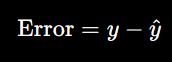

Where:

| Symbol      | Meaning                     |
| ----------- | --------------------------- |
| (y)         | Actual value                |
| (\hat{y})   | Predicted value             |
| (y-\hat{y}) | Prediction error (Residual) |

Example:

| Actual | Predicted | Error |
| -----: | --------: | ----: |
|    100 |        90 |    10 |
|    100 |       105 |    -5 |
|    100 |       100 |     0 |

Notice:

* Positive error → Model predicted too low.
* Negative error → Model predicted too high.
* Zero error → Perfect prediction.

Most regression metrics are different ways of summarizing these errors across all samples.

---

# Types of Regression Metrics

The most commonly used regression metrics in scikit-learn are:

| Metric                   | Full Form                    | Measures                        |
| ------------------------ | ---------------------------- | ------------------------------- |
| MAE                      | Mean Absolute Error          | Average absolute error          |
| MSE                      | Mean Squared Error           | Average squared error           |
| RMSE                     | Root Mean Squared Error      | Square root of MSE              |
| R² Score                 | Coefficient of Determination | Goodness of fit                 |
| Explained Variance Score | Explained Variance           | Variance explained by the model |
| Max Error                | Maximum Error                | Largest prediction error        |

> **Note:** MAE, MSE, Explained Variance, Max Error, and R² are directly available in `sklearn.metrics`. RMSE is obtained by taking the square root of MSE (or by using the `squared=False` option in older versions; in newer versions, use the dedicated RMSE function if available).

---

# Which Direction is Better?

Not every metric follows the same rule.

| Metric             | Ideal Value | Better Direction |
| ------------------ | ----------: | ---------------- |
| MAE                |           0 | Lower            |
| MSE                |           0 | Lower            |
| RMSE               |           0 | Lower            |
| Max Error          |           0 | Lower            |
| R² Score           |           1 | Higher           |
| Explained Variance |           1 | Higher           |

---

# Understanding Error Magnitude

Suppose the actual value is **100**.

| Prediction | Error | Good?        |
| ---------: | ----: | ------------ |
|         99 |     1 | ✅ Excellent  |
|         95 |     5 | ✅ Good       |
|         90 |    10 | ⚠ Acceptable |
|         70 |    30 | ❌ Poor       |

Smaller errors generally indicate better model performance.

---

# Characteristics of Common Metrics

| Metric | Unit                | Sensitive to Outliers | Easy to Interpret |
| ------ | ------------------- | --------------------- | ----------------- |
| MAE    | Same as target      | No                    | Yes               |
| MSE    | Squared target unit | Yes                   | Moderate          |
| RMSE   | Same as target      | Yes                   | Yes               |
| R²     | Unitless            | Indirectly            | Yes               |

---

# When to Use Which Metric?

| Situation                             | Recommended Metric | Why?                                                      |
| ------------------------------------- | ------------------ | --------------------------------------------------------- |
| General regression                    | RMSE               | Penalizes large errors while staying in the target's unit |
| Equal importance to every error       | MAE                | Treats all errors equally                                 |
| Large errors are especially costly    | MSE or RMSE        | Squaring increases the impact of large errors             |
| Comparing different regression models | R² Score           | Measures goodness of fit                                  |
| Reporting average prediction error    | MAE                | Easy to explain to stakeholders                           |

---

# Advantages of Using Regression Metrics

| Advantage                        | Explanation                                             |
| -------------------------------- | ------------------------------------------------------- |
| Quantifies model performance     | Gives an objective measure instead of visual inspection |
| Enables model comparison         | Makes it easy to compare different algorithms           |
| Helps hyperparameter tuning      | Used during model optimization                          |
| Detects overfitting/underfitting | Compare training and testing metric values              |
| Standardized evaluation          | Widely used across ML libraries                         |

---

# Limitations

| Limitation                           | Explanation                             |
| ------------------------------------ | --------------------------------------- |
| No single best metric                | Choice depends on the business problem  |
| Metrics emphasize different errors   | MAE and MSE may rank models differently |
| Outliers affect some metrics heavily | Especially MSE and RMSE                 |
| Doesn't explain *why* errors occur   | Only summarizes performance             |

---

# Real-World Applications

| Domain                  | Example Target     |
| ----------------------- | ------------------ |
| House Price Prediction  | House price        |
| Stock Price Forecasting | Future stock value |
| Sales Forecasting       | Monthly sales      |
| Weather Forecasting     | Temperature        |
| Demand Prediction       | Product demand     |
| Energy Consumption      | Electricity usage  |

---

# Comparison of Major Metrics

| Metric | Formula Idea            | Best Value | Outlier Sensitive | Unit                |      |                |
| ------ | ----------------------- | ---------: | ----------------- | ------------------- | ---- | -------------- |
| MAE    | Average (               |  y-\hat{y} | )                 | 0                   | ❌ No | Same as target |
| MSE    | Average ((y-\hat{y})^2) |          0 | ✅ Yes             | Squared target unit |      |                |
| RMSE   | (\sqrt{\text{MSE}})     |          0 | ✅ Yes             | Same as target      |      |                |
| R²     | Variance explained      |          1 | Indirectly        | Unitless            |      |                |

---

# Metrics Available in `sklearn.metrics`

| Metric                   | Function                                                                              |
| ------------------------ | ------------------------------------------------------------------------------------- |
| Mean Absolute Error      | `mean_absolute_error()`                                                               |
| Mean Squared Error       | `mean_squared_error()`                                                                |
| Root Mean Squared Error* | `root_mean_squared_error()` *(or derived from MSE depending on scikit-learn version)* |
| R² Score                 | `r2_score()`                                                                          |
| Explained Variance       | `explained_variance_score()`                                                          |
| Max Error                | `max_error()`                                                                         |

---

# Key Takeaways

* Regression metrics evaluate **how close predictions are to actual values**.
* They are computed using the **prediction error (residual)**.
* Different metrics measure error in different ways.
* **Lower is better** for MAE, MSE, RMSE, and Max Error.
* **Higher is better** for R² Score and Explained Variance.
* The choice of metric depends on the problem and the importance of large prediction errors.

# Section 2 — Import & Functions

Unlike algorithms such as `LinearRegression` or `LogisticRegression`, **regression metrics are functions, not classes**.

Therefore:

* ❌ No constructor
* ❌ No model object
* ✅ Just import the required metric and call it.

---

# Import

```python
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    root_mean_squared_error,
    r2_score,
    explained_variance_score,
    max_error
)
```

> **Note:** `root_mean_squared_error()` is available in newer versions of scikit-learn (1.4+). In older versions, compute RMSE using:
>
> ```python
> import numpy as np
> rmse = np.sqrt(mean_squared_error(y_true, y_pred))
> ```

---

# Available Regression Metric Functions

| Function                     | Purpose                  | Best Value |
| ---------------------------- | ------------------------ | ---------- |
| `mean_absolute_error()`      | Average absolute error   | 0          |
| `mean_squared_error()`       | Average squared error    | 0          |
| `root_mean_squared_error()`  | Square root of MSE       | 0          |
| `r2_score()`                 | Goodness of fit          | 1          |
| `explained_variance_score()` | Explained variance       | 1          |
| `max_error()`                | Largest prediction error | 0          |

---

# Common Parameters

Almost every regression metric follows the same pattern.

```python
metric(y_true, y_pred)
```

| Parameter | Description             |
| --------- | ----------------------- |
| `y_true`  | Actual target values    |
| `y_pred`  | Predicted target values |

Example:

```python
mae = mean_absolute_error(y_test, predictions)
```

---

# 1. mean_absolute_error()

Computes the average absolute difference between actual and predicted values.

## Syntax

```python
mean_absolute_error(
    y_true,
    y_pred,
    *,
    sample_weight=None,
    multioutput='uniform_average'
)
```

---

### Important Parameters

| Parameter       | Default             | Description              | Common Usage |
| --------------- | ------------------- | ------------------------ | ------------ |
| `y_true`        | —                   | Actual values            | Required     |
| `y_pred`        | —                   | Predicted values         | Required     |
| `sample_weight` | `None`              | Weight for each sample   | Rare         |
| `multioutput`   | `'uniform_average'` | Multi-output aggregation | Keep default |

---

### Returns

```python
float
```

Example:

```python
mae = mean_absolute_error(y_test, predictions)

print(mae)
```

Output

```text
2.54
```

---

# 2. mean_squared_error()

Calculates the average squared prediction error.

## Syntax

```python
mean_squared_error(
    y_true,
    y_pred,
    *,
    sample_weight=None,
    multioutput='uniform_average'
)
```

---

### Important Parameters

| Parameter       | Default             | Description              | Common Usage |
| --------------- | ------------------- | ------------------------ | ------------ |
| `y_true`        | —                   | Actual values            | Required     |
| `y_pred`        | —                   | Predicted values         | Required     |
| `sample_weight` | `None`              | Sample weights           | Rare         |
| `multioutput`   | `'uniform_average'` | Multi-output aggregation | Keep default |

---

### Returns

```python
float
```

Example

```python
mse = mean_squared_error(y_test, predictions)

print(mse)
```

---

# 3. root_mean_squared_error()

Returns the Root Mean Squared Error.

## Syntax

```python
root_mean_squared_error(
    y_true,
    y_pred,
    *,
    sample_weight=None,
    multioutput='uniform_average'
)
```

---

### Parameters

Exactly the same as `mean_squared_error()`.

Example

```python
rmse = root_mean_squared_error(
    y_test,
    predictions
)
```

Older versions

```python
import numpy as np

rmse = np.sqrt(
    mean_squared_error(y_test, predictions)
)
```

---

# 4. r2_score()

Measures how well the model explains the variance in the target.

## Syntax

```python
r2_score(
    y_true,
    y_pred,
    *,
    sample_weight=None,
    multioutput='uniform_average',
    force_finite=True
)
```

---

### Important Parameters

| Parameter       | Default | Description                              |
| --------------- | ------- | ---------------------------------------- |
| `y_true`        | —       | Actual values                            |
| `y_pred`        | —       | Predicted values                         |
| `sample_weight` | `None`  | Sample weights                           |
| `force_finite`  | `True`  | Avoids NaN/Infinite values in edge cases |

Example

```python
r2 = r2_score(
    y_test,
    predictions
)

print(r2)
```

Output

```text
0.91
```

---

# 5. explained_variance_score()

Measures how much variance in the target is explained by the model.

## Syntax

```python
explained_variance_score(
    y_true,
    y_pred,
    *,
    sample_weight=None,
    multioutput='uniform_average',
    force_finite=True
)
```

Example

```python
ev = explained_variance_score(
    y_test,
    predictions
)
```

---

# 6. max_error()

Returns the largest prediction error.

## Syntax

```python
max_error(
    y_true,
    y_pred
)
```

Only two required parameters.

Example

```python
largest_error = max_error(
    y_test,
    predictions
)

print(largest_error)
```

---

# Return Values Summary

| Function                     | Returns |
| ---------------------------- | ------- |
| `mean_absolute_error()`      | Float   |
| `mean_squared_error()`       | Float   |
| `root_mean_squared_error()`  | Float   |
| `r2_score()`                 | Float   |
| `explained_variance_score()` | Float   |
| `max_error()`                | Float   |

---

# Which Function Should You Use?

| Goal                       | Function                     |
| -------------------------- | ---------------------------- |
| Average error              | `mean_absolute_error()`      |
| Penalize large errors      | `mean_squared_error()`       |
| Error in original unit     | `root_mean_squared_error()`  |
| Measure goodness of fit    | `r2_score()`                 |
| Measure explained variance | `explained_variance_score()` |
| Find worst prediction      | `max_error()`                |

---

# Recommended Usage

For most regression projects, these four metrics are sufficient:

```python
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    root_mean_squared_error,
    r2_score
)
```

These are the metrics you'll encounter most frequently in practice and interviews.

---

This completes **Section 2 — Import & Functions**.

> **Small correction to your original notebook plan:** Since regression metrics are **functions**, not estimators, this section is better titled **"Import & Functions"** instead of **"Import & Constructor."** That keeps the notebook technically accurate while maintaining the same overall 5-section structure.


## `multioutput`

**Definition:**
Specifies **how to combine the metric scores** when the model predicts **multiple target variables** (multi-output regression).

**Default:**

```python
multioutput='uniform_average'
```

→ Calculates the metric for each output separately and returns their **simple average**.

---

### Possible Values

| Value                 | Meaning                                                                                     |
| --------------------- | ------------------------------------------------------------------------------------------- |
| `'uniform_average'`   | Computes the metric for each output and returns the **equal (simple) average**. *(Default)* |
| `'raw_values'`        | Returns the metric for **each output separately** as an array.                              |
| `'variance_weighted'` | Returns a **weighted average**, where outputs with higher variance have greater influence.  |

---

### Example

Suppose:

```python
Output 1 Score = 0.90
Output 2 Score = 0.70
```

| `multioutput`         | Result                                           |
| --------------------- | ------------------------------------------------ |
| `'uniform_average'`   | `(0.90 + 0.70) / 2 = 0.80`                       |
| `'raw_values'`        | `[0.90, 0.70]`                                   |
| `'variance_weighted'` | Weighted average based on each output's variance |

> **Note:** If your model predicts only **one target**, `multioutput` has **no effect**.

---

# `sample_weight`

**Definition:**
Assigns a **weight (importance)** to each sample while calculating the metric.

**Default:**

```python
sample_weight=None
```

→ All samples are treated **equally** (weight = 1).

---

### Possible Values

| Value                             | Meaning                                                                                 |
| --------------------------------- | --------------------------------------------------------------------------------------- |
| `None`                            | Every sample has equal importance. *(Default)*                                          |
| Array-like (e.g., `[1, 1, 2, 5]`) | Assigns a weight to each sample. Larger weight = greater influence on the final metric. |

---

### Example

```python
sample_weight = [1, 1, 5]
```

| Sample | Weight | Meaning                           |
| ------ | -----: | --------------------------------- |
| 1      |      1 | Normal importance                 |
| 2      |      1 | Normal importance                 |
| 3      |      5 | 5× more important than the others |

> **Note:** The length of `sample_weight` must be equal to the number of samples in `y_true`.


# Section 3 — Regression Metric Functions (Deep Dive)

In the previous section, we learned **how to import** the metric functions.

In this section, we'll understand **what each metric actually measures**, **how it's calculated**, **how to interpret its value**, and **when to use it**.

---

## Example Data

We'll use the same data for all metrics.

```python
y_true = [10, 20, 30, 40, 50]
y_pred = [12, 18, 33, 37, 49]
```

Let's first calculate the prediction errors.

| Actual ((y)) | Predicted ((\hat{y})) | Error ((y-\hat{y})) | Absolute Error | Squared Error |
| ------------ | --------------------- | ------------------- | -------------- | ------------- |
| 10           | 12                    | -2                  | 2              | 4             |
| 20           | 18                    | 2                   | 2              | 4             |
| 30           | 33                    | -3                  | 3              | 9             |
| 40           | 37                    | 3                   | 3              | 9             |
| 50           | 49                    | 1                   | 1              | 1             |

We'll use this table throughout the section.

---

# 1. Mean Absolute Error (MAE)

## What is MAE?

MAE measures the **average absolute prediction error**.

It tells us:

> **"On average, how far are my predictions from the actual values?"**

---

## Formula

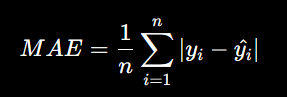

---

## Calculation

Absolute errors:

```text
2
2
3
3
1
```

Average:

[
\frac{2+2+3+3+1}{5}=2.2
]

```python
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_true, y_pred)

print(mae)
```

Output

```text
2.2
```

---

## Interpretation

The model is off by **2.2 units on average**.

If you're predicting house prices in lakhs:

```text
MAE = 2.2 lakhs
```

means your predictions are wrong by about ₹2.2 lakh on average.

---

## Properties

| Property          | Value          |
| ----------------- | -------------- |
| Best value        | 0              |
| Lower is better   | ✅              |
| Unit              | Same as target |
| Outlier sensitive | ❌ No           |
| Easy to interpret | ✅              |

---

## When to Use

* Every error is equally important.
* Need an easily understandable metric.
* Outliers should not dominate the evaluation.

---

# 2. Mean Squared Error (MSE)

## What is MSE?

MSE measures the **average squared prediction error**.

Instead of using absolute errors, it squares them.

---

## Formula

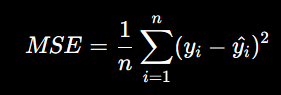

---

## Calculation

Squared errors:

```text
4
4
9
9
1
```

Average:

[
\frac{4+4+9+9+1}{5}=5.4
]

```python
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_true, y_pred)

print(mse)
```

Output

```text
5.4
```

---

## Why square the errors?

Consider two models.

### Model A

Errors:

```text
2
2
2
2
2
```

### Model B

Errors:

```text
0
0
0
0
10
```

Both have:

```text
MAE = 2
```

But MSE becomes:

| Model | MSE |
| ----- | --: |
| A     |   4 |
| B     |  20 |

MSE penalizes large mistakes much more heavily.

---

## Properties

| Property          | Value               |
| ----------------- | ------------------- |
| Best value        | 0                   |
| Lower is better   | ✅                   |
| Unit              | Squared target unit |
| Outlier sensitive | ✅ Yes               |
| Easy to interpret | ❌ Less intuitive    |

---

## When to Use

* Large prediction errors are very costly.
* Training many ML algorithms (e.g., Linear Regression optimizes MSE).

---

# 3. Root Mean Squared Error (RMSE)

## What is RMSE?

RMSE is simply the square root of MSE.

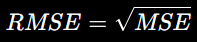

---

## Why do we need RMSE?

MSE has squared units.

Example:

If target is

```text
Temperature (°C)
```

Then

```text
MSE = °C²
```

which is hard to interpret.

RMSE converts it back to the original unit.

---

## Calculation

MSE

```text
5.4
```

RMSE

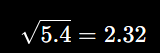

```python
from sklearn.metrics import root_mean_squared_error

rmse = root_mean_squared_error(y_true, y_pred)

print(rmse)
```

Output

```text
2.32
```

---

## Properties

| Property          | Value          |
| ----------------- | -------------- |
| Best value        | 0              |
| Lower is better   | ✅              |
| Unit              | Same as target |
| Outlier sensitive | ✅ Yes          |
| Easy to interpret | ✅              |

---

## MAE vs RMSE

| MAE                | RMSE                         |
| ------------------ | ---------------------------- |
| Equal penalty      | Larger errors penalized more |
| Robust to outliers | Sensitive to outliers        |
| Easier calculation | More common in ML papers     |

---

# 4. R² Score (Coefficient of Determination)

## What is R²?

R² measures **how well the model explains the variation in the target variable**.

Unlike MAE or RMSE, it is **not an error metric**.

It measures the quality of the fit.

---

## Formula

[
R^2
===

## 1

\frac{\text{Residual Sum of Squares (RSS)}}{\text{Total Sum of Squares (TSS)}}
]

You don't usually calculate this manually—`scikit-learn` does it for you.

---

## Range

| R²  | Meaning                                     |
| --- | ------------------------------------------- |
| 1.0 | Perfect predictions                         |
| 0.9 | Excellent fit                               |
| 0.7 | Good fit                                    |
| 0   | Model is no better than predicting the mean |
| < 0 | Worse than predicting the mean              |

---

Example:

```python
from sklearn.metrics import r2_score

r2 = r2_score(y_true, y_pred)

print(r2)
```

Output

```text
0.94
```

Interpretation:

The model explains **94% of the variance** in the target values.

---

## Properties

| Property         | Value |
| ---------------- | ----- |
| Best value       | 1     |
| Higher is better | ✅     |
| Unit             | None  |
| Can be negative  | ✅ Yes |

---

## When to Use

* Comparing regression models.
* Measuring overall goodness of fit.

---

# 5. Explained Variance Score

## What is it?

It measures how much of the variance in the target is captured by the model.

For good regression models, its value is often close to the R² score.

---

Example

```python
from sklearn.metrics import explained_variance_score

ev = explained_variance_score(
    y_true,
    y_pred
)

print(ev)
```

---

## Properties

| Property         | Value |
| ---------------- | ----- |
| Best value       | 1     |
| Higher is better | ✅     |
| Unit             | None  |

---

## When to Use

Mostly in advanced regression analysis.

For most practical projects, **R² is more commonly reported**.

---

# 6. Max Error

## What is it?

Returns the **largest absolute prediction error**.

Using our example:

Absolute errors:

```text
2
2
3
3
1
```

Largest:

```text
3
```

Example

```python
from sklearn.metrics import max_error

me = max_error(y_true, y_pred)

print(me)
```

Output

```text
3
```

---

## When to Use

Useful when **the single worst prediction matters**, such as:

* Safety-critical systems
* Medical devices
* Engineering applications

---

# Overall Comparison

| Metric             | Formula Idea           | Best Value | Outlier Sensitive        | Unit                | Higher/Lower Better |
| ------------------ | ---------------------- | ---------: | ------------------------ | ------------------- | ------------------- |
| MAE                | Average absolute error |          0 | ❌                        | Same as target      | Lower               |
| MSE                | Average squared error  |          0 | ✅                        | Squared target unit | Lower               |
| RMSE               | √MSE                   |          0 | ✅                        | Same as target      | Lower               |
| R²                 | Goodness of fit        |          1 | Indirectly               | Unitless            | Higher              |
| Explained Variance | Explained variance     |          1 | Indirectly               | Unitless            | Higher              |
| Max Error          | Largest absolute error |          0 | Depends on largest error | Same as target      | Lower               |

---

# Which Metrics Should You Report?

For most regression projects, reporting these four is considered a good practice:

```python
MAE
MSE
RMSE
R² Score
```

# Section 5 — Interview Questions & Hands-on Project

---

# Interview Questions

## Basic

### 1. What are regression metrics?

**Answer:**
Regression metrics measure how close a regression model's predictions are to the actual values.

---

### 2. What is the difference between MAE and MSE?

| MAE                        | MSE                         |
| -------------------------- | --------------------------- |
| Uses absolute error        | Uses squared error          |
| Less sensitive to outliers | More sensitive to outliers  |
| Easy to interpret          | Penalizes large errors more |

---

### 3. Why is RMSE often preferred over MSE?

**Answer:**

* RMSE has the **same unit as the target variable**.
* MSE is in **squared units**, making it harder to interpret.

---

### 4. Which metric is most affected by outliers?

**Answer:**

**MSE** and **RMSE**, because errors are squared before averaging.

---

### 5. What is the ideal value of MAE?

**Answer:**

```text
0
```

A value of **0** means every prediction is exactly correct.

---

### 6. What does an R² score of 0.92 mean?

**Answer:**

The model explains **92% of the variance** in the target variable.

---

### 7. Can the R² score be negative?

**Answer:**

Yes.

A negative R² means the model performs **worse than simply predicting the mean** of the target values.

---

### 8. Which metric would you report to a business stakeholder?

**Answer:**

**MAE**, because it is easy to understand.

Example:

> "On average, our predictions are off by ₹2.5 lakh."

---

### 9. When should you prefer RMSE over MAE?

**Answer:**

Use RMSE when **large prediction errors are much more costly** than small ones, because RMSE penalizes large errors more heavily.

---

### 10. Why shouldn't you rely on only one regression metric?

**Answer:**

Each metric measures performance differently.

* MAE → Average error
* MSE/RMSE → Penalize large errors
* R² → Goodness of fit

Using multiple metrics provides a more complete evaluation.